In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys
sys.path.append("../../")
from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader
from vi_rnn.datasets import Reaching, Reaching_Teacher
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from py_rnn.default_params import get_default_params
from mante import generate_mante_data
%matplotlib inline

In [2]:
train_teacher = True  # load already trained teacher model
data_dir = "../../data/student_teacher/"  # store inferred model
model_dir = "../../models/students/"  # store teacher RNN
cuda = True  # toggle if GPU is available

In [3]:
# initialise teacher RNN
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 2000
model_params["n_inp"] = 2
training_params["l2_rates_reg"] = 0.1
model_params['rank']= 1
model_params['ds'] = 2
training_params["neuromodulation"] = "postsynaptic" # rank, postsynaptic or presynaptic 
model_params["neuromodulation"] = "postsynaptic" # rank, postsynaptic or presynaptic 
model_params["train_b_rec"] = False # don't train the neuron biases
rnn_reach = RNN(model_params)

In [4]:

class RDM(Dataset):
    def __init__(self, task_params):
        """
        Initialize a random dot motion / perceptual decision making
         / evidence integration task (for teacher network)
        Args:
            task_params: dictionary containing task parameters

        Based on https://github.com/adrian-valente/populations_paper_code/blob/master/low_rank_rnns/rdm.py
        Dubreuil A., Valente A., Beiran M., Mastrogiuseppe F., Ostojic S. 
        The role of population structure in computations through neural dynamics
        Nature Neuroscience volume 25, pages 783–794 (2022)
        """

        self.task_params = task_params
        
        if "coherences" not in task_params or task_params["coherences"] is None:
            self.coherences = [-4, -2, -1, 1, 2, 4]
        else:
            self.coherences = task_params["coherences"]
        
        self.fixation_dur = task_params["fixation_dur"]
        self.stimulus_end = task_params["stimulus_dur"]+task_params["fixation_dur"]
        self.response_begin = self.stimulus_end+task_params["delay_dur"]
        self.total_duration =  self.response_begin +task_params["response_dur"]

        self.std = task_params["std"]
        self.scale = task_params["scale"]

    def __len__(self):
        return len(self.coherences)

    def __getitem__(self, idx):
        """
        Returns a trial

        Args:
            idx, trial index

        Returns:
            input, Tensor of size [seq_len, n_inp]
            target, Tensor of size [seq_len, n_inp]
            mask, Tensor of size [seq_len, n_inp]
        """

        inputs = self.std * torch.randn((self.total_duration, 2), dtype=torch.float32)

        targets = torch.zeros((self.total_duration, 1), dtype=torch.float32)
        mask = torch.zeros((self.total_duration, 1), dtype=torch.float32)

        coh_current = self.coherences[idx]
        inputs[self.fixation_dur:self.stimulus_end] += coh_current * self.scale
        targets[self.response_begin:] = np.sign(coh_current)
        mask[self.response_begin:] = 1
        return inputs, targets, mask
    
class Mante(Dataset): 

    def __init__(self, task_params): 
        """
        Initialize a random dot motion / perceptual decision making
         / evidence integration task (for teacher network)
        Args:
            task_params: dictionary containing task parameters

        Based on https://github.com/adrian-valente/populations_paper_code/blob/master/low_rank_rnns/rdm.py
        Dubreuil A., Valente A., Beiran M., Mastrogiuseppe F., Ostojic S. 
        The role of population structure in computations through neural dynamics
        Nature Neuroscience volume 25, pages 783–794 (2022)
        """

        self.task_params = task_params
        
        if "coherences" not in task_params or task_params["coherences"] is None:
            self.coherences = [-4, -2, -1, 1, 2, 4]
        else:
            self.coherences = task_params["coherences"]
        
        self.fixation_dur = task_params["fixation_dur"]
        self.stimulus_end = task_params["stimulus_dur"]+task_params["fixation_dur"]
        self.response_begin = self.stimulus_end+task_params["delay_dur"]
        self.total_duration =  self.response_begin +task_params["response_dur"]

        self.std = task_params["std"]
        self.scale = task_params["scale"]


    def __len__(self):
        return len(self.coherences)

    def __getitem__(self, idx):
        """
        Returns a trial

        Args:
            idx, trial index

        Returns:
            input, Tensor of size [seq_len, n_inp]
            target, Tensor of size [seq_len, n_inp]
            mask, Tensor of size [seq_len, n_inp]
        """

        inputs, targets, mask = generate_mante_data(1, coherences=self.coherences, fraction_validation_trials=0)
        return inputs[0], targets[0], mask[0]

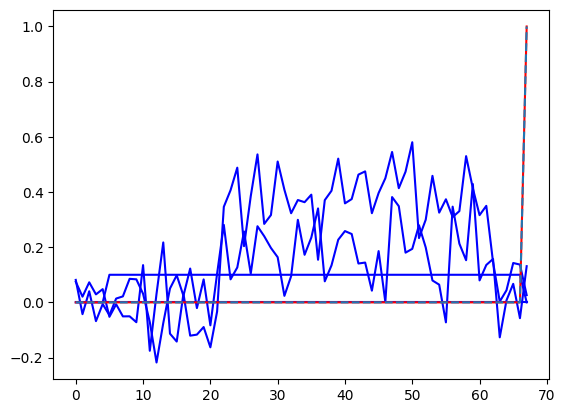

In [5]:
# Plot an example trial for teacher RNN

task_params_teacher = {
    "name": "rdm",
    "fixation_dur":5,
    "stimulus_dur":40,
    "delay_dur":5,
    "response_dur":1,
    "std":.1,
    "scale":.1}
# rdm = RDM(task_params_teacher)
mante = Mante(task_params_teacher)
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus, c='b')
plt.plot(targets, c='r')
plt.plot(mask, ls='--')

In [6]:
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_reach, training_params, mante, sync_wandb=False
    )
    save_rnn(
        data_dir + "mante_rnn_3",
        rnn_reach,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_reach, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + "mante_rnn_3"
    )

using l2 rates reg
epoch 2000 / 2000: time=63.2 s, task loss=0.10837, reg loss=0.44190
Done. Training took 63.2 sec.


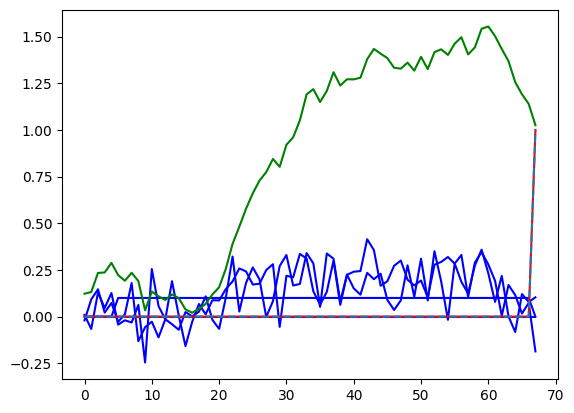

In [10]:
# Plot an example trial for teacher RNN

#task_params_teacher = {
#    "name": "rdm",
#    "fixation_dur":5,
#    "stimulus_dur":40,
#    "delay_dur":5,
#    "response_dur":1,
#    "std":.1,
#    "scale":.1}
task_params_teacher["response_dur"]=50
mante = Mante(task_params_teacher)
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus, c='b')
plt.plot(targets, c='r')
plt.plot(mask, ls='--')
out = rnn_reach(stimulus[:, :2].unsqueeze(0), s=stimulus[:, 2:].unsqueeze(0))
plt.plot(out[1].view(68).detach().numpy(), c='green')

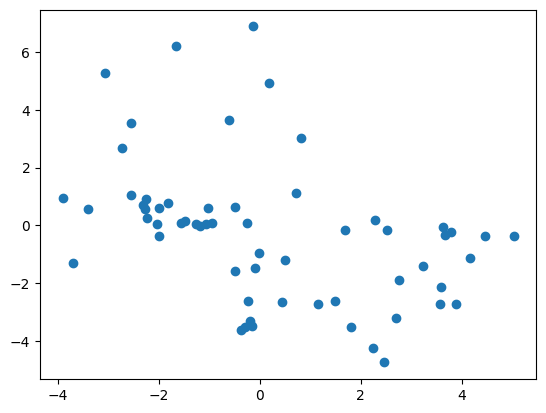

In [14]:
plt.scatter(rnn_reach.rnn.w_inp[0, :].detach().numpy(), rnn_reach.rnn.w_inp[1, :].detach().numpy())

In [24]:
# plot example output
inp = []
for i in range(6):
    stim,_,_ = mante[i]
    inp.append(stim)
inp = torch.stack(inp)
rates, pred = predict(rnn_reach, inp)
fig, axs = plt.subplots(2, figsize=(4, 2))
axs[0].plot(pred[0, :, :])
axs[1].set_xlabel("timesteps")
axs[1].plot(rnn_reach.rnn.nonlinearity(torch.from_numpy(rates[0])));

RuntimeError: mat1 and mat2 shapes cannot be multiplied (6x4 and 2x60)

In [23]:
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()
#I-=I@U@U.T
for i in range(len(inp)):
    plt.plot(rates[i,:,:]@U.numpy(),rates[i,:,:]@I.numpy().T)


NameError: name 'inp' is not defined

In [18]:
class Mante_Teacher(Dataset):
    def __init__(self, task_params, task_params_teacher, U, V, B, I, rnn, decay=0.9):
        """
        Initialize Teacher data for Reaching task
        Args:
            task_params: dictionary containing task parameters
            task_params_teacher: dictionary containing teacher task parameters
            U: torch.tensor; N x R, input to hidden weights
            V: torch.tensor; R x N, hidden to hidden weights
            B: torch.tensor; N, biases
            I: torch.tensor; n_inp x N, input to hidden weights
            decay: float, decay rate
        """

        self.R_z = task_params["R_z"]
        self.R_x = task_params["R_x"]

        # obtain teacher RNNs stimuli
        reaching = Mante(task_params_teacher)
        Reaching_loader = DataLoader(
            reaching, batch_size=reaching.__len__(), shuffle=False
        )
        n_repeats = task_params["n_trials"] //reaching.__len__()

        ss =[]
        for _ in range(n_repeats+1):
            s, _, _ = next(iter(Reaching_loader))  # x = trial,time,stims
            ss.append(s)
        self.stim = torch.concatenate(ss)[:task_params["n_trials"]]
        # self.s = self.stim[:, :, 2:]
        # self.stim = self.stim[:, :, :2]
        self.dur = self.stim.shape[1]
        self.n_trials=self.stim.shape[0]
        self.N = U.shape[0]
        self.non_lin = torch.nn.ReLU()

        # generate teacher data
        if "r0" in task_params:
            r0 = task_params["r0"]
        else:
            r0 = torch.randn(self.n_trials) * 0.1
        self.latents = torch.zeros(task_params["dz"], self.n_trials, self.dur, dtype=torch.float32)
        self.data = torch.zeros(self.N, self.n_trials, self.dur, dtype=torch.float32)
        self.latents[0, :, 0] = r0 
        self.latents[0, :, 0] += torch.randn(self.n_trials) * self.R_z
        v = torch.zeros(self.n_trials, self.dur, task_params["du"], dtype=torch.float32)
        for t in range(1, self.dur):
            v[:,t] = decay * v[:, t - 1] + (1-decay)*(self.stim[:, t - 1])
            self.latents[:, :, t] = decay * self.latents[:, :, t - 1]
            X = U @ self.latents[:, :, t - 1] + B.unsqueeze(1) + (v[:, t - 1] @ I).T
            if task_params["neuromodulation"] == "rank":
                self.latents[:, :, t] += (
                    torch.mul((rnn.A @ self.s[:, t, :].T).T, V @ self.non_lin(X)) + torch.randn(self.n_trials) * self.R_z
                )
            else: 
                self.latents[:, :, t] += (
                    V @ self.non_lin(X) + torch.randn(self.n_trials) * self.R_z
                )
        if task_params["out"] == "rates":
            for t in range(self.dur):
                self.data[:, :, t] = self.non_lin(
                    U @ self.latents[:, :, t] + B.unsqueeze(1) + (v[:, t] @ I).T
                )
        elif task_params["out"] == "currents":
            for t in range(self.dur):
                if task_params["neuromodulation"] == "postsynaptic": 
                    self.data[:, :, t] = U @ self.latents[:, :, t] + (v[:, t] @ I).T
        self.data += torch.randn(self.N, self.n_trials, self.dur) * self.R_x
        self.data_eval = self.data
        self.task_params = task_params
        self.v=v

    def __len__(self):
        """Return number of trials in an epoch"""
        return self.n_trials

    def __getitem__(self, idx):
        """
        Return a trial of length self.dur
        Args:
            idx (int): trial index
        Returns:
            trial (torch.tensor; dim_x x self.dur): trial of length self.dur
            stim (torch.tensor; n_inp x self.dur): stimulus
        """
        stim = self.stim[idx].T.to(device=self.data.device)
        return self.data[:, idx], stim#torch.zeros(0,self.dur,dtype=torch.float32,device=stim.device)#stim



In [19]:
batch_size = 4
task_params = {
    "name": "mante",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "n_trials": 400,
    "du": 4,
    "dz": 1,
    "neuromodulation": "none"
}
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()
task = Mante_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)

In [21]:
task.data.shape

torch.Size([60, 400, 68])

In [22]:
task.data = torch.permute(task.data, (1, 2, 0))
np.save('x_fr.npy', task.data.numpy())
# np.save('z.npy', task.s.numpy())
np.save('input.npy', task.stim.numpy())

In [37]:
# Generate data using teacher RNN, used for training student RNN
batch_size = 4
task_params = {
    "name": "rdm",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "n_trials": 400,
}
task = RDM_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=True)

NameError: name 'RDM_Teacher' is not defined

In [38]:
# Plot example latents of teacher RNN
colors = ["darkred", "firebrick", "tomato", "darkturquoise", "teal", "darkslategrey"]
for tr_i in range(20):
    latent_code = task.latents[:, tr_i]
    v = task.v[tr_i]
    stim = task.stim[tr_i]
    plt.plot(latent_code[0], v[:,0],color=colors[i%6])
    plt.xlabel(r"$z$")
    plt.ylabel(r"$v$")
    #plt.scatter(stim[50, 0], stim[50, 1])

NameError: name 'i' is not defined

In [15]:
# Initialise VI / student setup

dim_z = 1
dim_N = task_params["n_neurons"]
dim_x = task_params["n_neurons"]
dim_u = 1
bs = 10
cuda = True
n_epochs = 500
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_from": task_params["out"],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity"
}


training_params = {
    "lr": 1e-3,
    "lr_end": 1e-5,
    "opt_eps": 1e-8,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 50,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": True,
    "smooth_at_eval": False,
    "sim_v":True,
}


VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal": True,
}
vae = VAE(VAE_params)

using ReLU activation
using uniform init
weight scaler 1


In [16]:
vae, _,_,_ = load_model(name=model_dir + "rdm_student6")

using ReLU activation
using uniform init
weight scaler 1


In [17]:
# Train

train_VAE(
    vae,
    training_params,
    task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cuda
Learning rate decay factor 0.9908319448927676
Simulating V
torch.Size([100, 1, 1, 1])
no input
n outliers: 0.0010000000000000009
KL_x = 17.104, PS_dist = 0.467, Mean_rate_error = 51.611
epoch 1 loss: 1330.7397, ll: -1330.7397, ll_x: 1329.5732, ll_z: -1.2419 H: 2.4126, alpha: 0.94, lr: 0.001000, N_z: 0.0998, N_x: 0.1083
epoch 2 loss: 1284.2592, ll: -1284.2592, ll_x: 1283.1249, ll_z: -1.2649 H: 2.4056, alpha: 0.93, lr: 0.000991, N_z: 0.0994, N_x: 0.1087
epoch 3 loss: 1268.3617, ll: -1268.3617, ll_x: 1267.2453, ll_z: -1.2792 H: 2.4032, alpha: 0.93, lr: 0.000982, N_z: 0.0990, N_x: 0.1091
epoch 4 loss: 1249.7772, ll: -1249.7772, ll_x: 1248.6721, ll_z: -1.2866 H: 2.3997, alpha: 0.93, lr: 0.000973, N_z: 0.0985, N_x: 0.1096
epoch 5 loss: 1228.7513, ll: -1228.7513, ll_x: 1227.6575, ll_z: -1.2932 H: 2.3953, alpha: 0.93, lr: 0.000964, N_z: 0.0979, N_x: 0.1102
epoch 6 loss: 1203.8581, ll: -1203.8581, ll_x: 1202.7752, ll_z: -1.2992 H: 2.3907, alpha: 0.93, lr: 0.000955, N_z: 0.097

[]

In [61]:
#save_model(vae, training_params, task_params, name=model_dir + "rdm_student7")

In [62]:
vae.to_device("cpu")

In [63]:
from vi_rnn.utils import *
import matplotlib as mpl
from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic
from fixed_points.stability import PL_Jacobian
from matplotlib.markers import MarkerStyle
from matplotlib.colors import colorConverter as cc

In [64]:
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()


vae = orthogonalise_network(vae)
#rotation_matrix = torch.tensor([[0, -1], [1, 0]], dtype=torch.float32)
# vae = rotate_basis_vectors(vae,rotation_matrix)
tau, pV, pU, pB, pI = get_loadings(vae)

In [65]:
# extract teacher RNN data
batch_size=12
task_params['n_trials']=batch_size
task = RDM_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=False)

ratesGT = task.data
latent_codeGT = task.latents

# run the student RNN
with torch.no_grad():
    z0 = torch.zeros(batch_size,1)
    stim = task.stim.permute(0, 2, 1)
    dur=task.dur
    Z, v = vae.rnn.get_latent_time_series(time_steps=dur, z0=z0, u=stim, noise_scale=1,sim_v=True)
    Zn = Z.cpu().detach().numpy()[:, :, :, 0]
    data_gen = (
        vae.rnn.get_observation(Z, v=v,noise_scale=0).cpu().detach().numpy()[:, :, :, 0]
    )

torch.Size([12, 1])


In [66]:
Z.shape

torch.Size([12, 1, 100, 1])

In [67]:
tau

array(0.8890043, dtype=float32)

In [68]:
# Get all fixed points of teacher RNN
D_list, D_inds, z_listGT, n_inverses = find_fixed_points_analytic(
    np.ones(1) * 0.9, V.numpy(), U.numpy(), 0, -B.numpy()
)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau]), pV, pU, 0, pB
)

60
2
(120, 60)
(61, 60)
Found a fixed point
[9.23370353]
Found a fixed point
[-11.06482061]
Found a fixed point
[-0.36214173]
Done, found 3 fixed points
60
2
(120, 60)
(61, 60)
Found a fixed point
[9.30419907]
Found a fixed point
[-11.00550217]
Found a fixed point
[-0.54020213]
Done, found 3 fixed points


In [69]:
z_list

[array([9.30419907]), array([-11.00550217]), array([-0.54020213])]

In [70]:
#X = Z[:,0,:,0]*pI

In [71]:
#print(X.shape)

In [72]:

pI_orth = pI- ((pI.T@pU)/(pU.T@pU)*pU)

X = pI[:,:,np.newaxis]*v[:,0,:,0].unsqueeze(0).numpy() + pU[:,:,np.newaxis]*Z[:,0,:,0].unsqueeze(0).numpy()

v_orth = np.einsum('NBT,Ni->iBT',X,pI_orth/(pI_orth.T@pI_orth))[0]
print(v_orth.shape)
print(v[:,0,:,0].shape)
print(np.linalg.norm(v[:,0,:,0]-v_orth))

(12, 100)
torch.Size([12, 100])
7.3238425e-07


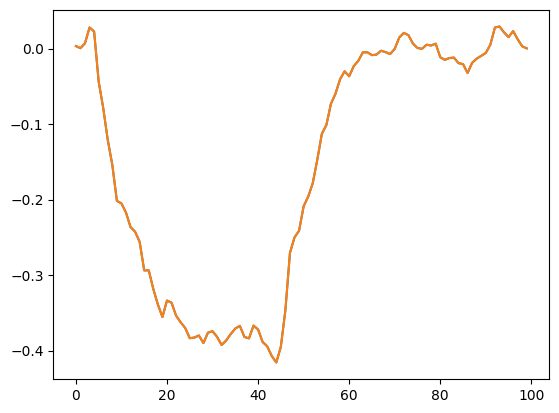

In [73]:
plt.plot(v_orth[0])
plt.plot(v[0,0,:,0])

In [78]:
X = pI[:,:,np.newaxis]*v[:,0,:,0].unsqueeze(0).numpy() + pU[:,:,np.newaxis]*Z[:,0,:,0].unsqueeze(0).numpy()


In [79]:
pI_orth = pI- ((pI.T@pU)/(pU.T@pU)*pU)
#X = 

In [80]:
latent_code[0].shape

torch.Size([100])

In [81]:
U.shape

torch.Size([60, 1])

In [82]:
I.shape

torch.Size([1, 60])

In [83]:
pI.T@pU

array([[1.587374]], dtype=float32)

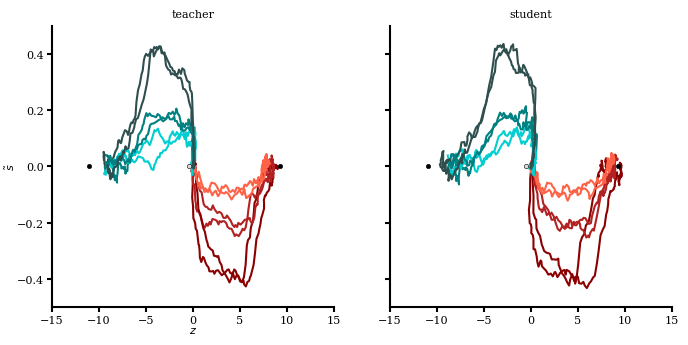

In [84]:
with mpl.rc_context(fname="../../generate_figures/matplotlibrc"):

    colors = ["darkred", "firebrick", "tomato", "darkturquoise", "teal", "darkslategrey"]
    fig,ax = plt.subplots(1,2, figsize=(8, 4),sharex=True,sharey=True)
    for i in range(batch_size):
        
        Zi = Z[i,0,:,0] + torch.from_numpy((pI.T@pU)).squeeze()*v[i,0,:,0]
        ax[1].plot(Zi,v[i,0,:,0].T,color=colors[i%6]);

        latent_code = task.latents[:, i]
        task_v = task.v[i]

        latent_orth = latent_code[0] + ((I@U)).squeeze()*task_v[:,0]
        ax[0].plot(latent_code[0], task_v[:,0],color=colors[i%6])
        #ax[0].plot(latent_orth, task_v[:,0],color=colors[i%6],ls='--')

        ax[0].set_xlabel(r"$z$")
        ax[0].set_ylabel(r"$\tilde{s}$")
        ax[0].set_xlabel(r"$z$")

        ax[0].set_title("teacher")
        ax[1].set_title("student")

    # marker style
    dot_s = 10
    dot_z = 100
    dot_ew = 0.4
    dot_s_st = 20
    dot_fill = "gainsboro"

            # Calculate stability of fixed points and plots
    for z in z_list:
        e, vec = np.linalg.eig(PL_Jacobian(pV, pU, -pB, np.diag(np.ones(1) * tau), z))
        if e[0] > 1:
            ax[1].scatter(
                z[0],
                0,
                s=dot_s,
                c=dot_fill,
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        else:
            ax[1].scatter(
                z[0],
                0,
                s=dot_s,
                c="black",
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
    
    for z in z_listGT:
        e, vec = np.linalg.eig(
            PL_Jacobian(V.numpy(), U.numpy(), B.numpy(), np.diag(np.ones(1) * 0.9), z)
        )
        if e[0] > 1:
            ax[0].scatter(
                z[0],
                0,
                s=dot_s,
                c=dot_fill,
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        else:
            ax[0].scatter(
                z[0],
                0,
                s=dot_s,
                c="black",
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        
    ax[0].set_xlim(-15,15)
    ax[0].set_ylim(-.5,.5)
    ax[0].set_box_aspect(1)
    ax[1].set_box_aspect(1)
    plt.savefig("../../figures/inputs.svg")

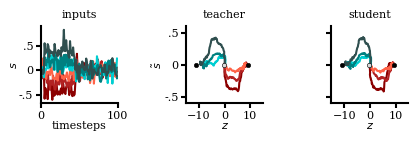

In [96]:
with mpl.rc_context(fname="../../generate_figures/matplotlibrc"):

    colors = ["darkred", "firebrick", "tomato", "darkturquoise", "teal", "darkslategrey"]
    fig,ax = plt.subplots(1,3, figsize=(5, 1))#,gridspec_kw=dict( wspace=[0,1]) )#,sharex=True,sharey=True)
    for i in range(6):
        ax[2].plot(Z[i,0,:,0].T,v[i,0,:,0].T,color=colors[i%6]);
        latent_code = task.latents[:, i]
        task_v = task.v[i]
        ax[1].plot(latent_code[0], task_v[:,0],color=colors[i%6])
        ax[0].plot(task.stim[i,:,0],color=colors[i%6]);
    ax[1].set_xlabel(r"$z$")
    ax[1].set_ylabel(r"$\tilde{s}$")
    ax[0].set_ylabel(r"$s$")
    ax[0].set_xlabel("timesteps")
    ax[2].set_xlabel(r"$z$")
    ax[1].set_title("teacher")
    ax[2].set_title("student")
    # marker style
    dot_s = 10
    dot_z = 100
    dot_ew = 0.4
    dot_s_st = 20
    dot_fill = "gainsboro"

            # Calculate stability of fixed points and plots
    for z in z_list:
        e, vec = np.linalg.eig(PL_Jacobian(pV, pU, -pB, np.diag(np.ones(1) * tau), z))
        if e[0] > 1:
            ax[2].scatter(
                z[0],
                0,
                s=dot_s,
                c=dot_fill,
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        else:
            ax[2].scatter(
                z[0],
                0,
                s=dot_s,
                c="black",
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
    
    for z in z_listGT:
        e, vec = np.linalg.eig(
            PL_Jacobian(V.numpy(), U.numpy(), B.numpy(), np.diag(np.ones(1) * 0.9), z)
        )
        if e[0] > 1:
            ax[1].scatter(
                z[0],
                0,
                s=dot_s,
                c=dot_fill,
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        else:
            ax[1].scatter(
                z[0],
                0,
                s=dot_s,
                c="black",
                edgecolor="black",
                lw=dot_ew,
                marker=MarkerStyle("o"),
                zorder=dot_z,
            )
        
    ax[1].set_xlim(-15,15)
    ax[1].set_ylim(-.6,.6)
    ax[2].set_xlim(-15,15)
    ax[2].set_ylim(-.6,.6)
    ax[2].set_ylim(-.6,.6)
    ax[0].set_box_aspect(1)
    ax[1].set_box_aspect(1)
    ax[2].set_box_aspect(1)
    ax[2].set_yticklabels([])
    ax[0].set_yticks([-.5,0,.5])
    plt.subplots_adjust(wspace=.5)

    ax[0].set_yticklabels(['-.5','0','.5'])
    ax[1].set_yticks([-.5,0,.5])
    ax[1].set_yticklabels(['-.5','0','.5'])
    ax[0].set_xlim(0,100)
    ax[0].set_title("inputs")
    plt.savefig("../../figures/inputs.pdf")
    plt.savefig("../../figures/inputs.png")

In [45]:
# Get all fixed points of teacher RNN
D_list, D_inds, z_listGT, n_inverses = find_fixed_points_analytic(
    np.ones(1) * 0.9, V.numpy(), U.numpy(), 0, -B.numpy()
)

# Get all fixed points of student RNN
D_list, D_inds, z_list, n_inverses = find_fixed_points_analytic(
    np.array([tau]), pV, pU, 0, pB
)

60
2
(120, 60)
(61, 60)
Found a fixed point
[9.23370353]
Found a fixed point
[-11.06482061]
Found a fixed point
[-0.36214173]
Done, found 3 fixed points
60
2
(120, 60)
(61, 60)
Found a fixed point
[9.30420232]
Found a fixed point
[-11.00556326]
Found a fixed point
[-0.54020103]
Done, found 3 fixed points
